# SEEDS Data Exploration

In [80]:
pip install matplotlib geopandas numpy scipy folium plotly

Note: you may need to restart the kernel to use updated packages.


In [81]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import os

## 1- Leeds Boundary

First isolate the boundaries of Leeds Local Authority, from LA UK dataset of ONS.

<Axes: >

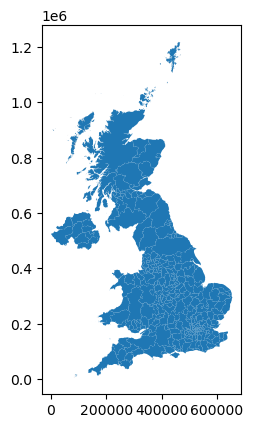

In [82]:
#Load file with different LAs in UK from ONS
UK_LAs = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\Local_Authority_Districts_May_2024_Boundaries_UK_BFE_6583563793708892075\LAD_MAY_2024_UK_BFE.shp")
UK_LAs.plot()

In [83]:
UK_LAs.head()

,LAD24CD,LAD24NM,LAD24NMW,BNG_E,BNG_N,LONG,LAT,geometry
0,E06000001,Hartlepool,None,447161,531473,-1.27017,54.6761,"POLYGON ((447213.9 537036.104, 447228.798 5370..."
1,E06000002,Middlesbrough,None,451141,516887,-1.21099,54.5447,"POLYGON ((448489.897 522071.798, 448592.597 52..."
2,E06000003,Redcar and Cleveland,None,464330,519596,-1.00656,54.5675,"POLYGON ((455553.038 528401.602, 455732.806 52..."
3,E06000004,Stockton-on-Tees,None,444940,518179,-1.30664,54.5569,"POLYGON ((444157.002 527956.304, 444165.898 52..."
4,E06000005,Darlington,None,428029,515648,-1.56835,54.5353,"POLYGON ((423496.602 524724.299, 423497.204 52..."


<Axes: >

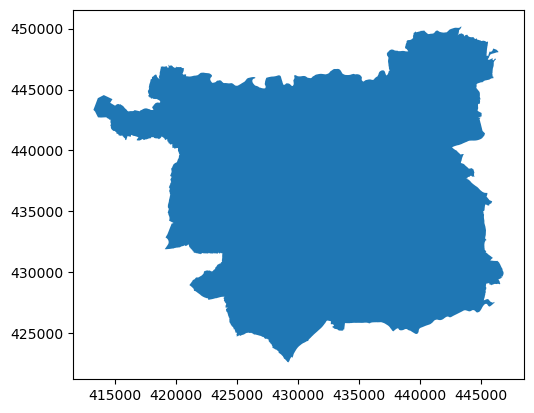

In [84]:
#Keep only Leeds LA
Leeds = UK_LAs[UK_LAs['LAD24NM'] == 'Leeds']
Leeds.plot()

In [85]:
#Check CRS
print(Leeds.crs)

EPSG:27700


## 2- Green Spaces - OS Data

Then clip the OS green spaces data to isolate the green spaces only in Leeds LA.

<Axes: >

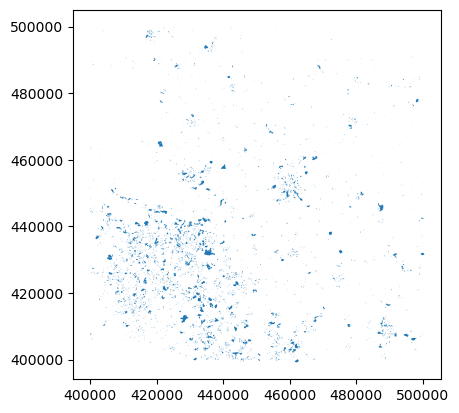

In [86]:
#Load file with green spaces from OS
Green_Spaces = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\OS Open Greenspace (ESRI Shape File) SE\data\SE_GreenspaceSite.shp")
Green_Spaces.plot()

In [87]:
Green_Spaces.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9729 entries, 0 to 9728
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         9729 non-null   object  
 1   function   9729 non-null   object  
 2   distName1  2601 non-null   object  
 3   distName2  23 non-null     object  
 4   distName3  0 non-null      object  
 5   distName4  0 non-null      object  
 6   geometry   9729 non-null   geometry
dtypes: geometry(1), object(6)
memory usage: 532.2+ KB


In [88]:
#Check CRS
print(Green_Spaces.crs)

EPSG:27700


c:\ProgramData\anaconda3\envs\timeseries_311\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: >

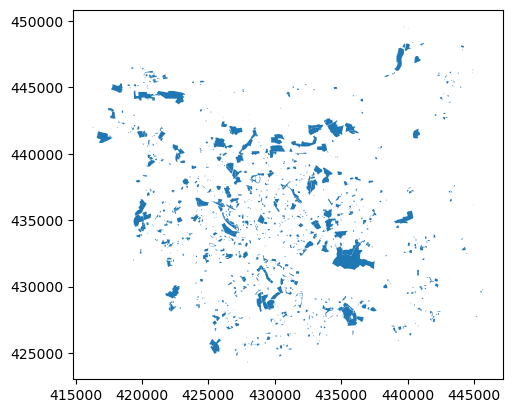

In [89]:
#Clip green spaces only in Leeds
Leeds['outline'] = 1
Leeds_outline = Leeds.dissolve(by= 'outline')

Green_Spaces = gpd.clip(Green_Spaces, Leeds_outline)
Green_Spaces.plot()

In [90]:
Green_Spaces.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1490 entries, 5418 to 7761
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   id         1490 non-null   object  
 1   function   1490 non-null   object  
 2   distName1  474 non-null    object  
 3   distName2  6 non-null      object  
 4   distName3  0 non-null      object  
 5   distName4  0 non-null      object  
 6   geometry   1490 non-null   geometry
dtypes: geometry(1), object(6)
memory usage: 93.1+ KB


So have 1490 green spaces in Leeds according to OS.

## 3- Geological Data - Digimap

A- Geological Indicators of flooding

<Axes: >

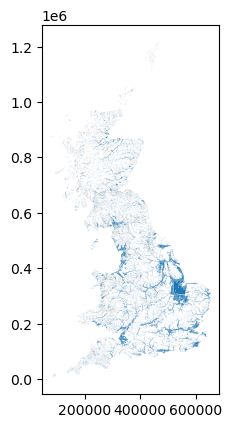

In [91]:
#Load file
Flood = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\Download_geology+SE_2966618\gi-flooding_6370739\GeologicalIndicatorsFloodingGB_v6.shp")
Flood.plot()

<Axes: >

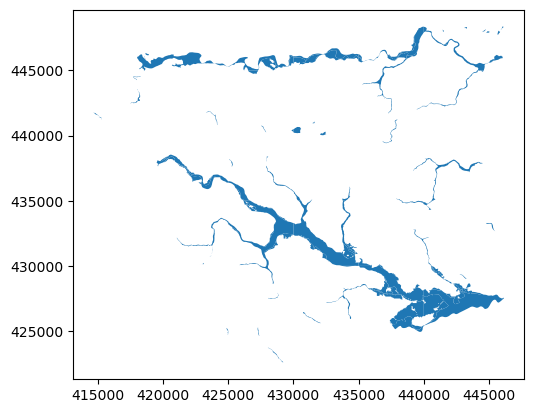

In [92]:
#Clip only in Leeds
Flood = gpd.clip(Flood, Leeds_outline)
Flood.plot()

B- Soil Parent

In [93]:
#Open all shapefiles in folder

folder_path = r"C:\Users\qxnq723\Desktop\Project_2\Datasets\Download_geology+SE_2966618\soil-parent_6370741\se"

gdfs = []

#Loop through all files in folder
for file in os.listdir(folder_path):
    if file.endswith('.shp'):
        shp_path = os.path.join(folder_path, file)
        gdf = gpd.read_file(shp_path)
        gdfs.append(gdf)

#Combile all shapefiles
soil_parent = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

soil_parent.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 74201 entries, 0 to 74200
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   GEN_PMLITH  74201 non-null  object  
 1   ESB_DESC    74201 non-null  object  
 2   GEN_GRAIN   74201 non-null  object  
 3   SOIL_GROUP  74201 non-null  object  
 4   SOIL_DEPTH  74201 non-null  object  
 5   CACO3_RANK  74201 non-null  object  
 6   ESB_CODE    74201 non-null  object  
 7   SIMPLE_TEX  74201 non-null  object  
 8   WATER_ERZ   74201 non-null  object  
 9   WIND_ERZ    74201 non-null  object  
 10  SOIL_WASH   74201 non-null  object  
 11  Version     74201 non-null  object  
 12  UID         74201 non-null  object  
 13  geometry    74201 non-null  geometry
dtypes: geometry(1), object(13)
memory usage: 7.9+ MB


<Axes: >

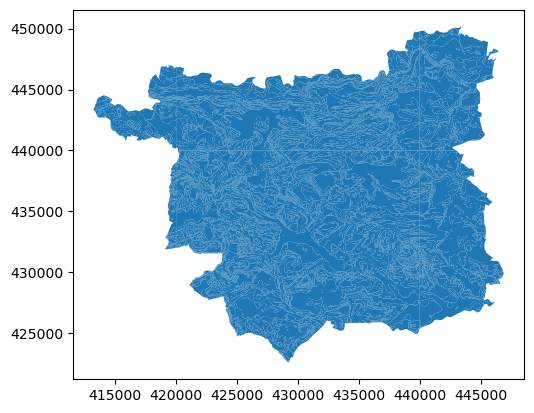

In [94]:
#Clip only in Leeds
soil_parent = gpd.clip(soil_parent, Leeds_outline)
soil_parent.plot()

In [95]:
soil_parent.head()

,GEN_PMLITH,ESB_DESC,GEN_GRAIN,SOIL_GROUP,SOIL_DEPTH,CACO3_RANK,ESB_CODE,SIMPLE_TEX,WATER_ERZ,WIND_ERZ,SOIL_WASH,Version,UID,geometry
30984,MUDSTONE-SANDSTONE,MUDSTONE AND SANDSTONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,INTERMEDIATE-SHALLOW,NONE,131_121,CLAYEY LOAM TO SANDY LOAM,Moderate. Rills may form during very wet perio...,Soil is not prone to wind erosion,Run off seen in some years during wet periods,v6.1,bgsn:SPMv61_1322255,"POLYGON ((428464.965 423360.581, 428468.981 42..."
30739,MUDSTONE-SANDSTONE,MUDSTONE AND SANDSTONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,INTERMEDIATE-SHALLOW,NONE,131_121,CLAYEY LOAM TO SANDY LOAM,"Low. Sediment rarely seen to move, but be awar...",Soil is not prone to wind erosion,Run off seen in some years during VERY wet per...,v6.1,bgsn:SPMv61_1319103,"POLYGON ((429098 422718, 429087 422730, 429069..."
34692,SANDSTONE,SANDSTONE,ARENACEOUS,MEDIUM TO HEAVY,SHALLOW,NONE,121,LOAM TO SANDY LOAM,High. Rills likely to form during very wet per...,Soil may be prone to wind erosion,Run off seen in some years during wet periods,v6.1,bgsn:SPMv61_1979458,"POLYGON ((428975 422956.831, 428956.991 422975..."
34947,SANDSTONE,SANDSTONE,ARENACEOUS,MEDIUM TO HEAVY,SHALLOW,NONE,121,LOAM TO SANDY LOAM,Low-moderate. Rarely rills may form during ver...,Soil may be prone to wind erosion,Run off seen in some years during VERY wet per...,v6.1,bgsn:SPMv61_1981987,"POLYGON ((431755.108 425575, 431775 425554.416..."
31056,MUDSTONE-SANDSTONE,MUDSTONE AND SANDSTONE,ARGILLIC - ARENACEOUS,HEAVY TO MEDIUM,INTERMEDIATE-SHALLOW,NONE,131_121,CLAYEY LOAM TO SANDY LOAM,Moderate. Rills may form during very wet perio...,Soil is not prone to wind erosion,Run off seen in some years during wet periods,v6.1,bgsn:SPMv61_1322347,"POLYGON ((431258 425480, 431265.687 425483.048..."


In [96]:
soil_parent['SOIL_GROUP'].value_counts()

SOIL_GROUP
LIGHT(SILTY) TO MEDIUM(SILTY) TO HEAVY    1962
MEDIUM TO HEAVY                           1520
LIGHT(SILTY) TO MEDIUM(SILTY)             1081
MEDIUM TO LIGHT(SILTY) TO HEAVY            702
LIGHT(SANDY) TO MEDIUM(SANDY)              480
HEAVY TO MEDIUM                            395
ALL                                        346
MEDIUM(SILTY)                               72
MEDIUM                                      32
MEDIUM TO LIGHT(SILTY)                      17
Name: count, dtype: int64

In [97]:
soil_parent['GEN_GRAIN'].value_counts()

GEN_GRAIN
ARGILLIC - ARENACEOUS         2898
ARENACEOUS                    2640
MIXED (ARGILLIC-RUDACEOUS)     694
ARENACEOUS - RUDACEOUS         286
ARGILLACEOUS                    80
PEAT                             9
Name: count, dtype: int64

In [98]:
soil_parent['ESB_DESC'].value_counts()

ESB_DESC
SANDSTONE                                         2640
MUDSTONE AND SANDSTONE                            2049
GLACIAL TILL                                       681
DOLOSTONE                                          314
RIVERINE CLAY AND FLOODPLAIN SANDS AND GRAVEL      289
COLLUVIUM                                          206
RIVER TERRACE SAND/GRAVEL                          156
GLACIOFLUVIAL DEPOSITS                             126
CLAYSTONE/MUDSTONE                                  73
LIMESTONE                                           32
UNCONSOLIDATED FLUVIAL AND GLACIGENIC DEPOSITS      13
PEAT                                                 9
GLACIOLACUSTRINE                                     7
UNCONSOLIDATED GLACIAL DEPOSITS                      5
FLOODPLAIN SAND/GRAVEL                               4
LACUSTRINE SAND AND SILT                             3
Name: count, dtype: int64

In [99]:
soil_parent['SIMPLE_TEX'].value_counts()

SIMPLE_TEX
LOAM TO SANDY LOAM           2375
CLAYEY LOAM TO SANDY LOAM    2255
CLAYEY LOAM TO SILTY LOAM     692
SAND TO SANDY LOAM            395
LOAM TO SILTY                 314
CLAY TO SANDY LOAM            294
SANDY LOAM                    156
SILTY LOAM                     72
LOAM TO SILTY LOAM             32
VARIED, LOCALLY PEATY          13
PEAT                            9
Name: count, dtype: int64

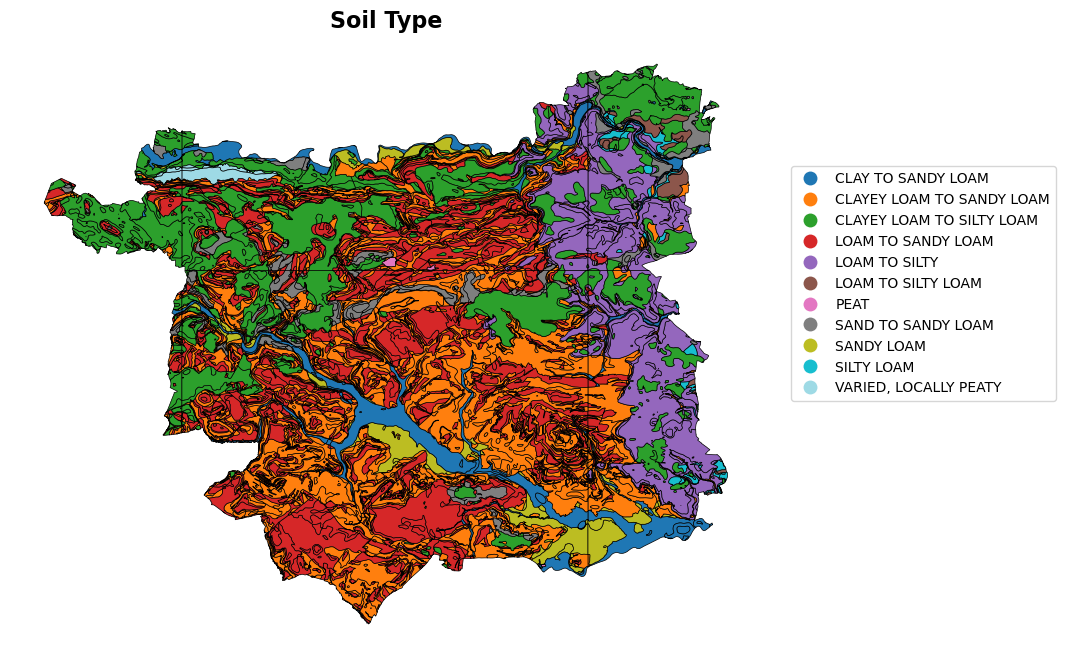

In [100]:
#Create map of soil type

#Choose which description to map
column = 'SIMPLE_TEX'

fig, ax = plt.subplots(figsize=(10, 8))

soil_parent.plot(column = column,
                 categorical= True,
                 legend = True,
                 cmap= 'tab20',
                 edgecolor= 'black',
                 linewidth= 0.5,
                 ax= ax,
                 legend_kwds= {
                     'loc': 'upper right',
                     'bbox_to_anchor': (1.4, 0.8)
                 }
)

ax.set_title('Soil Type', fontsize= 16, fontweight= 'bold')
ax.set_axis_off()
plt.show()

## 4- Land cover - Digimap OS

In [101]:
#Load file
LandCover = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\Download_Land+cover+dig_2976346\lcm-2024-vec_6387524\lcm-2024-vec_6387524.gpkg")
LandCover.head()
print(LandCover.crs)

EPSG:27700


In [102]:
#Clip only in Leeds
LandCover = gpd.clip(LandCover, Leeds_outline)
LandCover.head()

,_conf,_hist,_mode,_n,_purity,_stdev,_agg,gid,geometry
261013,56.76,"1:9,3:9,4:135,20:2,21:14",4,169,79.88,22.56,4,5460832,"MULTIPOLYGON (((424823.61 425230.08, 424825.44..."
222059,57.88,"1:15,3:4,4:3,20:3,21:41",21,66,62.12,19.44,10,4643857,"POLYGON ((424845.391 425302.807, 424871.35 425..."
147252,62.08,"4:13,20:4,21:56",21,73,76.71,16.19,10,3087901,"MULTIPOLYGON (((424823.222 425229.929, 424816...."
309443,57.64,"1:9,3:36,4:49,20:12,21:175",21,281,62.28,21.82,10,6477587,"POLYGON ((424718.629 425342.699, 424723.698 42..."
177521,79.28,"4:71,21:43",4,114,62.28,20.26,4,3721705,"POLYGON ((424931.28 425538.854, 424828.41 4254..."


In [103]:
#Comvert the _mode to integer
LandCover['_mode'] = LandCover['_mode'].astype('Int64')

In [104]:
#Add column with land cover associated with each _mode

#Create list of identifiers (based on documentation)
LC_identifiers = {
    'Deciduous woodland': 1,
    'Coniferous woodland': 2,
    'Arable': 3,
    'Improve grassland': 4,
    'Neutral grassland': 5,
    'Calcareous grassland':	6,
    'Acid grassland': 7,
    'Fen': 8,
    'Heather': 9,
    'Heather grassland': 10,
    'Bog': 11,
    'Inland rock': 12,
    'Saltwater': 13,
    'Freshwater': 14,
    'Supralittoral rock': 15,
    'Supralittoral sediment': 16,
    'Littoral  rock': 17,
    'Littoral sediment': 18,
    'Saltmarsh': 19,
    'Urban': 20,
    'Suburban': 21
}

#Reverse dictionary: ID to label
id_to_label = {v: k for k, v in LC_identifiers.items()}

#Create new column
LandCover['Land_Cover_Type'] = LandCover['_mode'].map(id_to_label)
LandCover.head()


,_conf,_hist,_mode,_n,_purity,_stdev,_agg,gid,geometry,Land_Cover_Type
261013,56.76,"1:9,3:9,4:135,20:2,21:14",4,169,79.88,22.56,4,5460832,"MULTIPOLYGON (((424823.61 425230.08, 424825.44...",Improve grassland
222059,57.88,"1:15,3:4,4:3,20:3,21:41",21,66,62.12,19.44,10,4643857,"POLYGON ((424845.391 425302.807, 424871.35 425...",Suburban
147252,62.08,"4:13,20:4,21:56",21,73,76.71,16.19,10,3087901,"MULTIPOLYGON (((424823.222 425229.929, 424816....",Suburban
309443,57.64,"1:9,3:36,4:49,20:12,21:175",21,281,62.28,21.82,10,6477587,"POLYGON ((424718.629 425342.699, 424723.698 42...",Suburban
177521,79.28,"4:71,21:43",4,114,62.28,20.26,4,3721705,"POLYGON ((424931.28 425538.854, 424828.41 4254...",Improve grassland


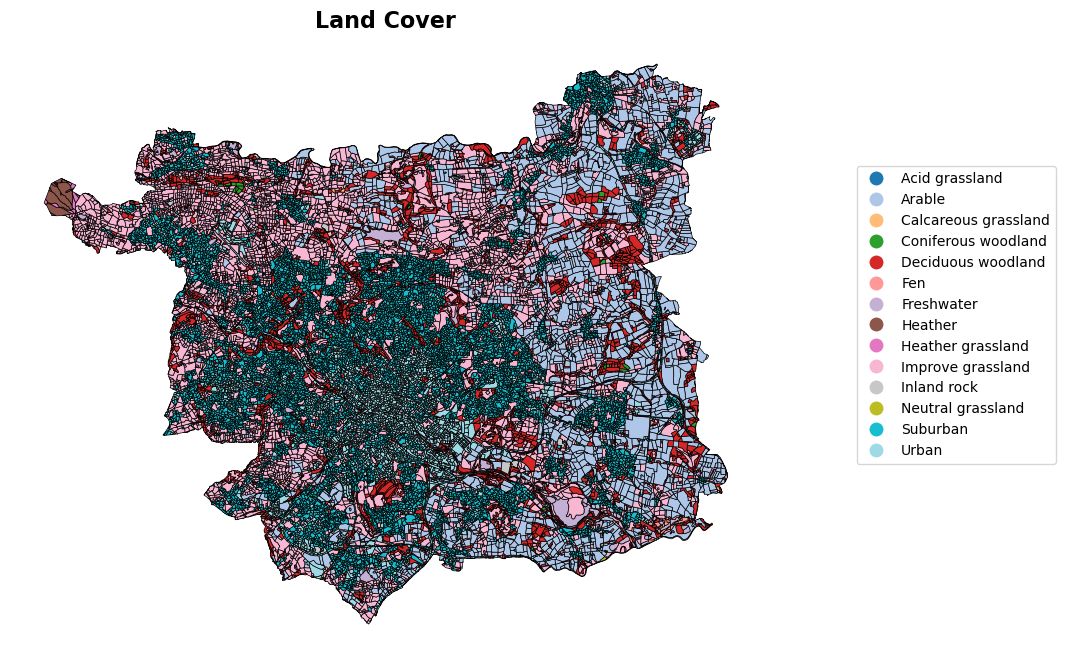

In [105]:
#Create map of land cover

fig, ax = plt.subplots(figsize=(10, 8))

LandCover.plot(column = 'Land_Cover_Type',
                 categorical= True,
                 legend = True,
                 cmap= 'tab20',
                 edgecolor= 'black',
                 linewidth= 0.5,
                 ax= ax,
                 legend_kwds= {
                     'loc': 'upper right',
                     'bbox_to_anchor': (1.4, 0.8)
                 }
)

ax.set_title('Land Cover', fontsize= 16, fontweight= 'bold')
ax.set_axis_off()
plt.show()

## 5- Allotment Locations - Leeds Council (web scraping)

The polygons of allotments in Leeds are scraped from the Leeds Council ArcGis webpage.

In [106]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [107]:
import requests
from shapely.geometry import Point, shape

url= "https://services1.arcgis.com/brSffcdOV7o1pDVT/arcgis/rest/services/Allotments/FeatureServer/1/query"

headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif 'Lat' in row and 'Lon' in row:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(row['Lon'], row['Lat'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to dataframe and export CSV
df = pd.DataFrame(all_rows)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:27700')
gdf.to_file('allotments_polygons.gpkg', driver= 'GPKG')

print('Done:', len(gdf), 'rows exported')

Fetched 2000 records
Done: 133 rows exported


In [108]:
#Load data
allotments = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Code\allotments_polygons.gpkg")
allotments.info()
print(allotments.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   OBJECTID        133 non-null    int64   
 1   SITEREF         133 non-null    object  
 2   BOUNDNUM        133 non-null    object  
 3   SITEALIAS       133 non-null    object  
 4   SITESORT        133 non-null    int64   
 5   SITEADDRESS     133 non-null    object  
 6   SITEPLAN        133 non-null    object  
 7   TYPOLOGYTXT     133 non-null    object  
 8   SITEPLANPOLICY  133 non-null    object  
 9   HMCAREA         133 non-null    object  
 10  AREAHA          133 non-null    float64 
 11  PLANREFLABEL    133 non-null    object  
 12  WARD_NAME       133 non-null    object  
 13  Demand          130 non-null    float64 
 14  AG3Score        130 non-null    float64 
 15  Shape__Area     133 non-null    float64 
 16  Shape__Length   133 non-null    float64 
 17  geometry

In [109]:
print(allotments.is_valid.value_counts())

True     129
False      4
Name: count, dtype: int64


<Axes: >

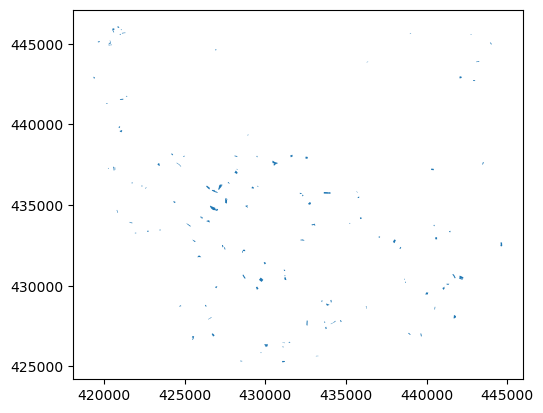

In [110]:
#Fix invalid geometries
allotments['geometry'] = allotments.buffer(0)
#Clip only in Leeds
allotments = gpd.clip(allotments, Leeds_outline)
allotments.plot()

The information about allotment contacts are scraped from the Leeds Council ArcGis webpage

In [133]:
import requests
from shapely.geometry import Point, shape

url= "https://services1.arcgis.com/brSffcdOV7o1pDVT/ArcGIS/rest/services/Allotments_contacts/FeatureServer/0/query"

headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif 'Lat' in row and 'Lon' in row:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(row['Lon'], row['Lat'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to dataframe and export CSV
df = pd.DataFrame(all_rows)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:4326')
gdf = gdf.to_crs('EPSG:27700')
gdf.to_file('allotments_contacts_points.gpkg', driver= 'GPKG')

print('Done:', len(gdf), 'rows exported')

Fetched 2000 records
Done: 101 rows exported


In [134]:
#Load data
allotment_contacts = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Code\allotments_contacts_points.gpkg")
allotment_contacts.info()
print(allotment_contacts.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Site_name      101 non-null    object  
 1   Postcode       101 non-null    object  
 2   Council_co     101 non-null    object  
 3   Contact_de     101 non-null    object  
 4   Lat            101 non-null    float64 
 5   Lon            101 non-null    float64 
 6   BNG_x          101 non-null    float64 
 7   BNG_y          101 non-null    float64 
 8   geometry_type  101 non-null    object  
 9   geometry       101 non-null    geometry
dtypes: float64(4), geometry(1), object(5)
memory usage: 8.0+ KB
EPSG:27700


In [135]:
allotment_contacts.head()

,Site_name,Postcode,Council_co,Contact_de,Lat,Lon,BNG_x,BNG_y,geometry_type,geometry
0,Shafton Lane,LS10,Allotment association,mailto:neilcrozier1@gmail.com,53.785638,-1.566593,428653.9935,432231.4731,point,POINT (428653.708 432233.239)
1,Whitehouse Farm,LS10,Allotment association,mailto:allotments@leeds.gov.uk,53.768740,-1.527512,431241.4312,430367.8091,point,POINT (431241.145 430369.607)
2,Old Lane,LS11,Allotment association,mailto:oldlanelotts@gmail.com,53.771632,-1.566968,428638.7744,430673.0339,point,POINT (428638.495 430674.799)
3,Parkside Beeston,LS11,Allotment association,mailto:allotments@leeds.gov.uk,53.764568,-1.554212,429484.4391,429892.2868,point,POINT (429484.162 429894.068)
4,Clarkesfield,LS11,Allotment association,mailto:allotments@leeds.gov.uk,53.769477,-1.551131,429684.0971,430439.7324,point,POINT (429683.813 430441.513)


<Axes: >

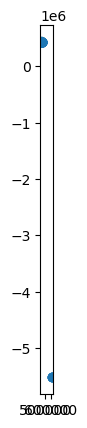

In [136]:
allotment_contacts.plot()

True    101
Name: count, dtype: int64


<Axes: >

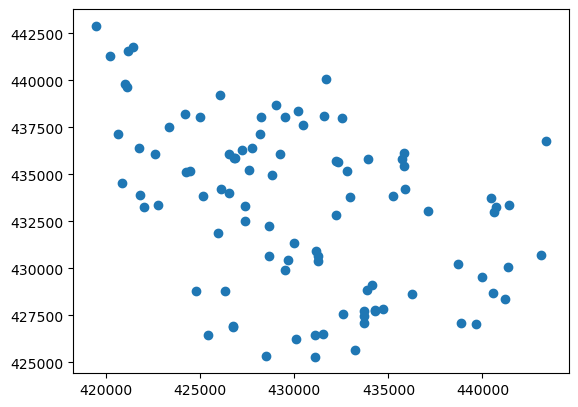

In [137]:
#Check if geometries are valid
print(allotment_contacts.is_valid.value_counts())
#Clip only in Leeds
allotment_contacts = gpd.clip(allotment_contacts, Leeds_outline)
allotment_contacts.plot()

## 5- Brownfield Land Locations - Leeds Council (web scraping)

In [ ]:
import requests

url= "https://mapservices.leeds.gov.uk/arcgis/rest/services/Public/Strategic_Planning/MapServer/14/query"

headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #retrun all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry', {})
    
        #Polygons
        if 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= geom['rings'] #store polygon geometry
        #Polyline
        elif 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= geom['paths'] #store line geometry
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to dataframe and export CSV
df = pd.DataFrame(all_rows)
df.to_csv('brownfield_polygons.csv', index= False)

print('Done:', len(df), 'rows exported')

In [ ]:
Brownfield = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project_2\Code\brownfield_polygons.csv")
Brownfield.head()

In [ ]:
#Apply conversion function to data
Brownfield['geometry'] = Brownfield['geometry'].apply(convert_geom)
#Convert to GeoDataFrame
Brownfield = gpd.GeoDataFrame(Brownfield, geometry='geometry')
Brownfield.info()

In [ ]:
Brownfield.plot()

In [ ]:
print(Brownfield.crs) #returns None
#Assign a CRS
Brownfield = Brownfield.set_crs(epsg= 27700)
print(Brownfield.crs)

In [ ]:
print(Brownfield.is_valid.value_counts())

In [ ]:
#Fix invalid geometries
Brownfield['geometry'] = Brownfield.buffer(0)
#Clip only in Leeds
Brownfield = gpd.clip(Brownfield, Leeds_outline)
Brownfield.plot()

## 6 - Soil Chemistry (Heavy Metals UKSO Data)

In [ ]:
pip install rasterio

In [ ]:
import rasterio

HeavyMetal = rasterio.open(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\UKSO_HeavyMetals\UK_topsoil_data_geotiff_As_v1\As_v1.tif")
print(HeavyMetal.crs)
print(HeavyMetal.profile)

In [ ]:
#Convert Geotiff raster into vector polygons geometries
from rasterio.features import shapes
from shapely.geometry import shape

with rasterio.open(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\UKSO_HeavyMetals\UK_topsoil_data_geotiff_As_v1\As_v1.tif") as HM:
    raster = HM.read(1)
    transform = HM.transform
    
    #Extract polygons
    results = (
        {'properties': {'value': v}, 'geometry': s}
        for s , v in shapes(raster, transform= transform)
    )

#Convert to GeoDataFrame
geoms = list(results)
HeavyMetals = gpd.GeoDataFrame.from_features(geoms)
#Set CRS
HeavyMetals.set_crs(HM.crs, inplace=True)
HeavyMetals.head()


In [ ]:
#Build one combined dataset with all heavy metals 
# and
#Convert Geotiff raster into vector polygons geometries

#Import libraries
import rasterio #to open GeoTIFF files and raster data
from rasterio.features import shapes #to convert raster to polygons
from pathlib import Path #file/folder handling

#Create path to folder with heavy metal files
folder_path = Path(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\UKSO_HeavyMetals")

#Create empty list to contain the GeoDataFrames
all_gdfs = []

#Loop through every subfolder for tif files
for tif_path in folder_path.rglob("*.tif"):
    print(f"Processing: {tif_path.name}")
    
    #Extract name of heavymetal from subfolders string
    subfolder_name = tif_path.parent.name
    metal = subfolder_name.split('geotiff_')[1].split('_v1')[0]

    #Open GeoTIFF file, and read band 1 into array 
    # (TIFF files have only 1 band)
    with rasterio.open(tif_path) as source:
        raster = source.read(1)
        
        #Convert raster data into polygons
        # s = polygon geometry
        # v = raster value
        results = (
            {'properties': {'value': v}, 
             'geometry': s}
            for s , v in shapes(raster, transform= source.transform) # convert pixel coordinates into real-world coordinates
            if v != source.nodata #skip pixels with no data
        )


        #Convert all polygon features into list and then into a GeoDataFrame
        gdf= gpd.GeoDataFrame.from_features(list(results))
        #Assign UK 27700 CRS
        gdf.set_crs(source.crs, inplace= True)
        
        #Track source file
        gdf['source_file'] = tif_path.stem
        #Add metal name column
        gdf['metal'] = metal
        #Add the GeoDataFrame into master list (1 GeoDataFrame per TIFF)
        all_gdfs.append(gdf)

#Convert into big table
HeavyMetals = pd.concat(all_gdfs, ignore_index = True)
HeavyMetals = gpd.GeoDataFrame(HeavyMetals, geometry= 'geometry')
HeavyMetals.head()

In [ ]:
HeavyMetals.info()

In [ ]:
HeavyMetals['metal'].value_counts()

In [ ]:
#Clip only in Leeds
HeavyMetals = gpd.clip(HeavyMetals, Leeds_outline)
HeavyMetals.plot()

In [ ]:
#Create map of heavy metal

#Choose which heavy metal to map
plot_metal = 'Cu'
#Filter dataset for that metal only
m = HeavyMetals[HeavyMetals['metal'] == plot_metal]

fig, ax = plt.subplots(figsize=(10, 8))

m.plot(column = 'value',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': f'{plot_metal} Concentration (mg/kg)'}
)

ax.set_title(f'Heavy Metal Concentration Heatmap - {plot_metal}', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

## 7- Soil pH - UKSO

In [ ]:
Soil_pH = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\UKSO_Soil_pH\data\CS_topsoil_pH_bulkDensity.shp")
Soil_pH.info()

In [ ]:
print(Soil_pH.crs)

In [ ]:
#Clip only in Leeds
Soil_pH = gpd.clip(Soil_pH, Leeds_outline)

In [ ]:
Soil_pH.head()

PH_98 is the 'Mean value for soil pH in 1998 modelled by LCM_CLASS and CACO3_RANK', so that is used as pH value and is mapped.

In [ ]:
#Create map of pH in 1998

fig, ax = plt.subplots(figsize=(10, 8))

Soil_pH.plot(column = 'PH_98',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': 'pH'}
)

ax.set_title(f'pH in 1998 Heatmap', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()

## 8- TopSoil Carbon - UKSO

In [ ]:
Soil_SOM = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project_2\Datasets\UKSO_SoilCarbon\data\9e4451f8-23d3-40dc-9302-73e30ad3dd76\CS_topsoil_carbon.shp")
Soil_SOM.info()

In [ ]:
print(Soil_SOM.crs)

In [ ]:
#Clip only in Leeds
Soil_SOM = gpd.clip(Soil_SOM, Leeds_outline)

In [ ]:
Soil_SOM.head()

LOI_07 is the 'Mean value for soil loss-on-ignition in 2007 modelled by LCM_CLASS and DOM_GRAIN', which corresponds to the soil organic matter (SOM).

In [ ]:
#Create map of SOM in 2007

fig, ax = plt.subplots(figsize=(10, 8))

Soil_SOM.plot(column = 'LOI_07',
       legend = True,
       cmap= 'hot_r',
       edgecolor= 'black',
       linewidth= 0.5,
       ax= ax,
       legend_kwds= {'label': 'Loss-on-ignition (%)'}
)

ax.set_title(f'Soil Loss-In-Ignition in 2007 Heatmap', 
             fontsize= 16, 
             fontweight= 'bold')
ax.set_axis_off()
plt.show()